In [1]:
# Autonomous Forest Navigation
# Notebook 04: Occupancy Mapping

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Project paths
# ---------------------------------------------------------

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

PROCESSED_SCAN_FILE = (
    OUTPUTS_DIR
    / "processed_lidar"
    / "green_robosense_sample_processed.npz"
)

FUSION_RESULTS_FILE = (
    OUTPUTS_DIR
    / "green_ekf_fused_trajectory.csv"
)

print("OCCUPANCY MAPPING PROJECT SETUP")
print("=" * 70)

print("Python       :", sys.executable)
print("Working dir  :", CURRENT_DIR)
print("Project root :", PROJECT_ROOT)

print("\nRequired inputs:")

required_files = [
    PROCESSED_SCAN_FILE,
    FUSION_RESULTS_FILE
]

for file in required_files:
    print(
        f"{file.name:40s} -> "
        f"{'OK' if file.exists() else 'MISSING'}"
    )

OCCUPANCY MAPPING PROJECT SETUP
Python       : D:\Autonomous_Forest_Navigation\forest_env\python.exe
Working dir  : D:\Autonomous_Forest_Navigation\notebooks
Project root : D:\Autonomous_Forest_Navigation

Required inputs:
green_robosense_sample_processed.npz     -> OK
green_ekf_fused_trajectory.csv           -> OK


In [2]:
# Load processed LiDAR data and match the scan timestamp
# to the fused EKF trajectory.

# ---------------------------------------------------------
# 1. Load processed LiDAR scan
# ---------------------------------------------------------

processed_scan = np.load(
    PROCESSED_SCAN_FILE
)

xyz = processed_scan["xyz"]
ground_points = processed_scan["ground_points"]
obstacle_points = processed_scan["obstacle_points"]
high_vegetation = processed_scan["high_vegetation"]

scan_timestamp_us = int(
    processed_scan["scan_timestamp_us"][0]
)

scan_timestamp_s = (
    scan_timestamp_us / 1e6
)


# ---------------------------------------------------------
# 2. Load EKF fused trajectory
# ---------------------------------------------------------

fusion = pd.read_csv(
    FUSION_RESULTS_FILE
)

fusion_times = (
    fusion["timestamp"].to_numpy()
)


# ---------------------------------------------------------
# 3. Find EKF pose nearest to LiDAR scan timestamp
# ---------------------------------------------------------

nearest_idx = np.argmin(
    np.abs(
        fusion_times -
        scan_timestamp_s
    )
)

pose_row = fusion.iloc[
    nearest_idx
]

pose_timestamp = float(
    pose_row["timestamp"]
)

time_difference = (
    pose_timestamp -
    scan_timestamp_s
)

time_difference_ms = (
    time_difference * 1000
)


# ---------------------------------------------------------
# 4. Extract fused robot pose
# ---------------------------------------------------------

robot_x = float(
    pose_row["ekf_x"]
)

robot_y = float(
    pose_row["ekf_y"]
)

robot_yaw = float(
    pose_row["ekf_yaw"]
)

robot_yaw_deg = np.degrees(
    robot_yaw
)


# ---------------------------------------------------------
# 5. Read stored processing parameters
# ---------------------------------------------------------

stored_grid_size = float(
    processed_scan["grid_size"][0]
)

stored_ground_threshold = float(
    processed_scan["ground_threshold"][0]
)

stored_obstacle_min = float(
    processed_scan["obstacle_min_height"][0]
)

stored_obstacle_max = float(
    processed_scan["obstacle_max_height"][0]
)


# ---------------------------------------------------------
# 6. Summary
# ---------------------------------------------------------

print("LIDAR / EKF TEMPORAL ALIGNMENT")
print("=" * 70)

print(
    f"LiDAR timestamp      : "
    f"{scan_timestamp_s:.6f} s"
)

print(
    f"Nearest EKF timestamp: "
    f"{pose_timestamp:.6f} s"
)

print(
    f"Time difference      : "
    f"{time_difference_ms:.3f} ms"
)

print("\nROBOT POSE AT LIDAR SCAN")
print("=" * 70)

print(
    f"X                  : "
    f"{robot_x:.3f} m"
)

print(
    f"Y                  : "
    f"{robot_y:.3f} m"
)

print(
    f"Yaw                : "
    f"{robot_yaw:.5f} rad"
)

print(
    f"Yaw                : "
    f"{robot_yaw_deg:.3f} deg"
)

print("\nPROCESSED POINT CLOUD")
print("=" * 70)

print(
    f"All points          : "
    f"{len(xyz):,}"
)

print(
    f"Ground points       : "
    f"{len(ground_points):,}"
)

print(
    f"Obstacle points     : "
    f"{len(obstacle_points):,}"
)

print(
    f"High vegetation     : "
    f"{len(high_vegetation):,}"
)

print("\nSEGMENTATION PARAMETERS")
print("=" * 70)

print(
    f"Terrain grid size   : "
    f"{stored_grid_size:.2f} m"
)

print(
    f"Ground threshold    : "
    f"{stored_ground_threshold:.2f} m"
)

print(
    f"Obstacle height     : "
    f"{stored_obstacle_min:.2f} - "
    f"{stored_obstacle_max:.2f} m"
)

LIDAR / EKF TEMPORAL ALIGNMENT
LiDAR timestamp      : 1750951614.000699 s
Nearest EKF timestamp: 1750951614.000106 s
Time difference      : -0.593 ms

ROBOT POSE AT LIDAR SCAN
X                  : -71.677 m
Y                  : -23.365 m
Yaw                : 0.17514 rad
Yaw                : 10.035 deg

PROCESSED POINT CLOUD
All points          : 161,735
Ground points       : 95,845
Obstacle points     : 64,210
High vegetation     : 1,680

SEGMENTATION PARAMETERS
Terrain grid size   : 0.50 m
Ground threshold    : 0.45 m
Obstacle height     : 0.45 - 2.50 m


LOCAL OCCUPANCY GRID
Map extent       : -35.0 to 35.0 m
Resolution       : 0.25 m/cell
Grid size        : 280 x 280

MAP STATISTICS
Unknown cells     : 67,934 (86.7 %)
Free cells        : 969 (1.2 %)
Occupied cells    : 9,497 (12.1 %)

ROBOT SAFETY
Robot radius      : 0.50 m
Safety margin     : 0.25 m
Inflation radius  : 0.75 m
Inflation cells   : 3


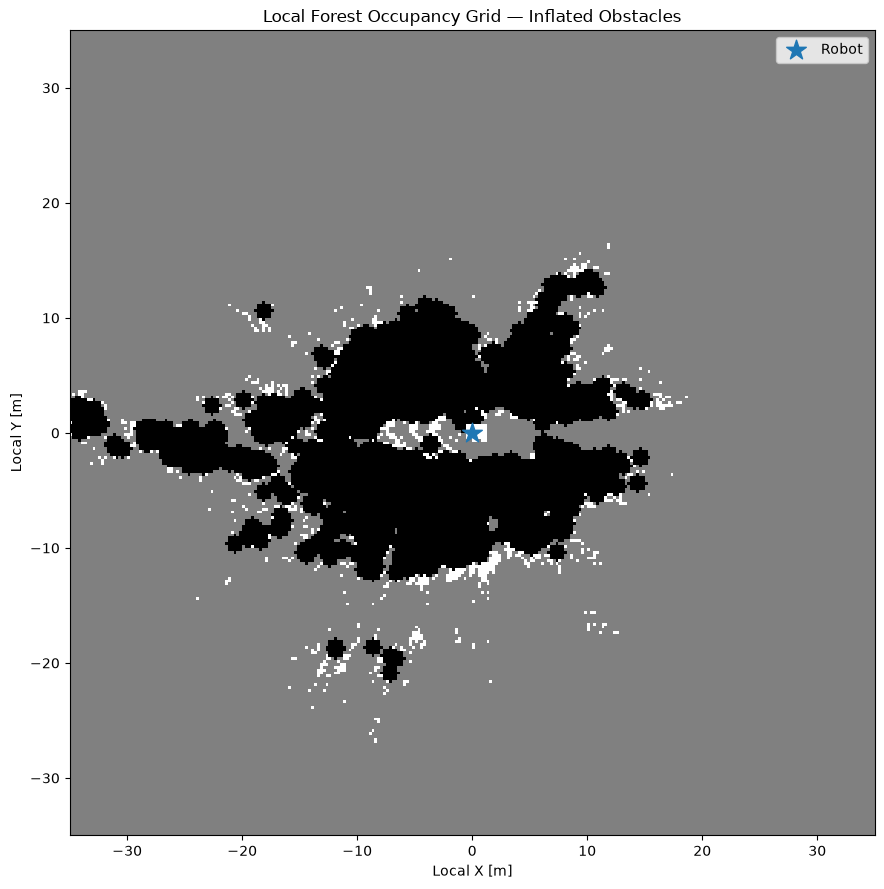


Figure saved:
D:\Autonomous_Forest_Navigation\figures\green_local_occupancy_grid.png


In [3]:
# Build a 2D local occupancy grid from the processed LiDAR scan

from scipy.ndimage import binary_dilation

# ---------------------------------------------------------
# 1. Occupancy-grid configuration
# ---------------------------------------------------------

MAP_RANGE = 35.0          # metres from robot
MAP_RESOLUTION = 0.25     # metres per cell

# Robot-footprint assumption for this prototype
ROBOT_RADIUS = 0.50       # m
SAFETY_MARGIN = 0.25      # m

INFLATION_RADIUS = (
    ROBOT_RADIUS +
    SAFETY_MARGIN
)

# Require more than one obstacle return before declaring
# a grid cell occupied
MIN_OBSTACLE_POINTS = 3


# ---------------------------------------------------------
# 2. Grid dimensions
# ---------------------------------------------------------

x_min = -MAP_RANGE
x_max = MAP_RANGE

y_min = -MAP_RANGE
y_max = MAP_RANGE

grid_width = int(
    np.ceil(
        (x_max - x_min) /
        MAP_RESOLUTION
    )
)

grid_height = int(
    np.ceil(
        (y_max - y_min) /
        MAP_RESOLUTION
    )
)

print("LOCAL OCCUPANCY GRID")
print("=" * 70)

print(
    f"Map extent       : "
    f"{x_min:.1f} to {x_max:.1f} m"
)

print(
    f"Resolution       : "
    f"{MAP_RESOLUTION:.2f} m/cell"
)

print(
    f"Grid size        : "
    f"{grid_width} x {grid_height}"
)


# ---------------------------------------------------------
# 3. Helper: convert XY coordinates to grid indices
# ---------------------------------------------------------

def xy_to_grid(points_xy):

    gx = np.floor(
        (points_xy[:, 0] - x_min) /
        MAP_RESOLUTION
    ).astype(int)

    gy = np.floor(
        (points_xy[:, 1] - y_min) /
        MAP_RESOLUTION
    ).astype(int)

    valid = (
        (gx >= 0) &
        (gx < grid_width) &
        (gy >= 0) &
        (gy < grid_height)
    )

    return gx[valid], gy[valid]


# ---------------------------------------------------------
# 4. Count ground evidence
# ---------------------------------------------------------

ground_x_idx, ground_y_idx = xy_to_grid(
    ground_points[:, :2]
)

ground_count = np.zeros(
    (grid_height, grid_width),
    dtype=np.uint16
)

np.add.at(
    ground_count,
    (
        ground_y_idx,
        ground_x_idx
    ),
    1
)


# ---------------------------------------------------------
# 5. Count obstacle evidence
# ---------------------------------------------------------

obs_x_idx, obs_y_idx = xy_to_grid(
    obstacle_points[:, :2]
)

obstacle_count = np.zeros(
    (grid_height, grid_width),
    dtype=np.uint16
)

np.add.at(
    obstacle_count,
    (
        obs_y_idx,
        obs_x_idx
    ),
    1
)


# ---------------------------------------------------------
# 6. Build raw occupancy classification
#
# - Unknown: no useful evidence
# - Free: ground observed
# - Occupied: enough obstacle returns
# ---------------------------------------------------------

occupancy_grid = np.full(
    (grid_height, grid_width),
    -1,
    dtype=np.int16
)

free_cells = (
    ground_count > 0
)

occupied_cells = (
    obstacle_count >= MIN_OBSTACLE_POINTS
)

occupancy_grid[
    free_cells
] = 0

# Occupied evidence takes priority
occupancy_grid[
    occupied_cells
] = 100


# ---------------------------------------------------------
# 7. Robot-size obstacle inflation
# ---------------------------------------------------------

inflation_cells = int(
    np.ceil(
        INFLATION_RADIUS /
        MAP_RESOLUTION
    )
)

yy, xx = np.ogrid[
    -inflation_cells:inflation_cells + 1,
    -inflation_cells:inflation_cells + 1
]

inflation_kernel = (
    xx ** 2 +
    yy ** 2
    <= inflation_cells ** 2
)

inflated_obstacles = binary_dilation(
    occupied_cells,
    structure=inflation_kernel
)

inflated_grid = occupancy_grid.copy()

inflated_grid[
    inflated_obstacles
] = 100


# ---------------------------------------------------------
# 8. Make sure the robot's immediate footprint is free
# ---------------------------------------------------------

robot_grid_x = int(
    (0.0 - x_min) /
    MAP_RESOLUTION
)

robot_grid_y = int(
    (0.0 - y_min) /
    MAP_RESOLUTION
)

robot_clearance_cells = int(
    np.ceil(
        ROBOT_RADIUS /
        MAP_RESOLUTION
    )
)

r0 = max(
    0,
    robot_grid_y - robot_clearance_cells
)

r1 = min(
    grid_height,
    robot_grid_y + robot_clearance_cells + 1
)

c0 = max(
    0,
    robot_grid_x - robot_clearance_cells
)

c1 = min(
    grid_width,
    robot_grid_x + robot_clearance_cells + 1
)

inflated_grid[
    r0:r1,
    c0:c1
] = 0


# ---------------------------------------------------------
# 9. Statistics
# ---------------------------------------------------------

unknown_count = np.sum(
    inflated_grid == -1
)

free_count = np.sum(
    inflated_grid == 0
)

occupied_count_final = np.sum(
    inflated_grid == 100
)

total_cells = inflated_grid.size

print("\nMAP STATISTICS")
print("=" * 70)

print(
    f"Unknown cells     : "
    f"{unknown_count:,} "
    f"({100 * unknown_count / total_cells:.1f} %)"
)

print(
    f"Free cells        : "
    f"{free_count:,} "
    f"({100 * free_count / total_cells:.1f} %)"
)

print(
    f"Occupied cells    : "
    f"{occupied_count_final:,} "
    f"({100 * occupied_count_final / total_cells:.1f} %)"
)

print("\nROBOT SAFETY")
print("=" * 70)

print(
    f"Robot radius      : "
    f"{ROBOT_RADIUS:.2f} m"
)

print(
    f"Safety margin     : "
    f"{SAFETY_MARGIN:.2f} m"
)

print(
    f"Inflation radius  : "
    f"{INFLATION_RADIUS:.2f} m"
)

print(
    f"Inflation cells   : "
    f"{inflation_cells}"
)


# ---------------------------------------------------------
# 10. Visualize raw occupancy map
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 9))

display_grid = np.zeros_like(
    inflated_grid,
    dtype=float
)

# Unknown
display_grid[
    inflated_grid == -1
] = 0.5

# Free
display_grid[
    inflated_grid == 0
] = 1.0

# Occupied
display_grid[
    inflated_grid == 100
] = 0.0

ax.imshow(
    display_grid,
    origin="lower",
    extent=[
        x_min,
        x_max,
        y_min,
        y_max
    ],
    interpolation="nearest",
    cmap="gray"
)

ax.scatter(
    0,
    0,
    marker="*",
    s=220,
    zorder=5,
    label="Robot"
)

ax.set_title(
    "Local Forest Occupancy Grid — Inflated Obstacles"
)

ax.set_xlabel("Local X [m]")
ax.set_ylabel("Local Y [m]")

ax.set_xlim(
    x_min,
    x_max
)

ax.set_ylim(
    y_min,
    y_max
)

ax.grid(False)
ax.legend()

plt.tight_layout()

occupancy_figure = (
    FIGURES_DIR /
    "green_local_occupancy_grid.png"
)

plt.savefig(
    occupancy_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved:")
print(occupancy_figure)

RAY-TRACING INPUT
Unique ground endpoints   : 4,451
Unique obstacle endpoints : 2,830

RAY-TRACED MAP STATISTICS
Unknown cells  : 64,908 (82.8 %)
Free cells     : 4,750 (6.1 %)
Occupied cells : 8,742 (11.2 %)

ROBOT-REACHABLE FREE SPACE
Connected free cells : 613
Reachable area       : 38.31 m²
Maximum reach        : 10.14 m


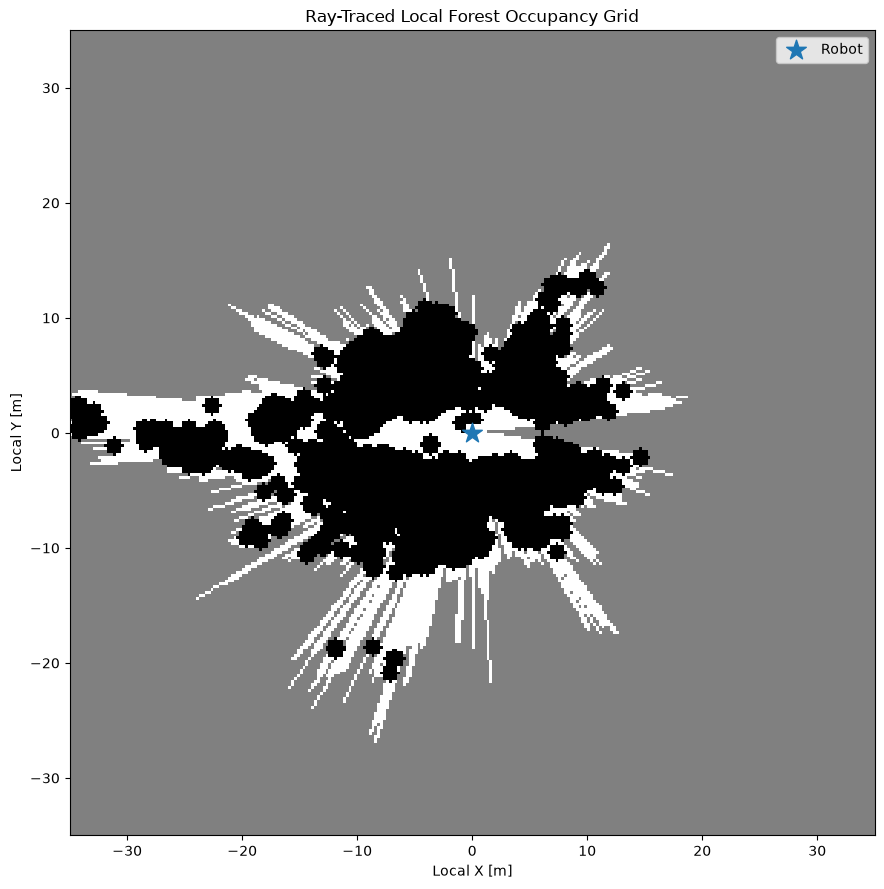


Figure saved:
D:\Autonomous_Forest_Navigation\figures\green_local_occupancy_grid_raytraced.png


In [4]:
# Improve the occupancy map using LiDAR ray tracing.
#
# Cells traversed by a laser ray are marked FREE.
# Obstacle endpoints are marked OCCUPIED.
# Areas never observed remain UNKNOWN.

from scipy.ndimage import binary_dilation, label

# ---------------------------------------------------------
# 1. Helper: Bresenham grid ray
# ---------------------------------------------------------

def bresenham_line(x0, y0, x1, y1):
    """
    Return integer grid cells along a line from
    (x0, y0) to (x1, y1).
    """

    cells = []

    dx = abs(x1 - x0)
    dy = abs(y1 - y0)

    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1

    err = dx - dy

    x = x0
    y = y0

    while True:

        cells.append((x, y))

        if x == x1 and y == y1:
            break

        e2 = 2 * err

        if e2 > -dy:
            err -= dy
            x += sx

        if e2 < dx:
            err += dx
            y += sy

    return cells


# ---------------------------------------------------------
# 2. Robot grid location
# ---------------------------------------------------------

robot_col = int(
    (0.0 - x_min) /
    MAP_RESOLUTION
)

robot_row = int(
    (0.0 - y_min) /
    MAP_RESOLUTION
)


# ---------------------------------------------------------
# 3. Determine obstacle endpoint cells
# ---------------------------------------------------------

MIN_OBSTACLE_POINTS_RAY = 4

occupied_endpoint_mask = (
    obstacle_count >= MIN_OBSTACLE_POINTS_RAY
)

occupied_rows, occupied_cols = np.where(
    occupied_endpoint_mask
)

occupied_endpoints = set(
    zip(
        occupied_cols.tolist(),
        occupied_rows.tolist()
    )
)


# ---------------------------------------------------------
# 4. Determine observed ground endpoint cells
# ---------------------------------------------------------

ground_rows, ground_cols = np.where(
    ground_count > 0
)

ground_endpoints = set(
    zip(
        ground_cols.tolist(),
        ground_rows.tolist()
    )
)

# Do not treat an occupied endpoint as ground
ground_endpoints = (
    ground_endpoints -
    occupied_endpoints
)

print("RAY-TRACING INPUT")
print("=" * 70)

print(
    f"Unique ground endpoints   : "
    f"{len(ground_endpoints):,}"
)

print(
    f"Unique obstacle endpoints : "
    f"{len(occupied_endpoints):,}"
)


# ---------------------------------------------------------
# 5. Ray-trace free space
# ---------------------------------------------------------

ray_free = np.zeros(
    (grid_height, grid_width),
    dtype=bool
)


# Ground returns:
# entire ray including endpoint is free
for col, row in ground_endpoints:

    ray = bresenham_line(
        robot_col,
        robot_row,
        col,
        row
    )

    for c, r in ray:

        if (
            0 <= c < grid_width
            and 0 <= r < grid_height
        ):
            ray_free[r, c] = True


# Obstacle returns:
# all cells BEFORE the obstacle endpoint are free
for col, row in occupied_endpoints:

    ray = bresenham_line(
        robot_col,
        robot_row,
        col,
        row
    )

    for c, r in ray[:-1]:

        if (
            0 <= c < grid_width
            and 0 <= r < grid_height
        ):
            ray_free[r, c] = True


# ---------------------------------------------------------
# 6. Build ray-traced occupancy grid
# ---------------------------------------------------------

ray_grid = np.full(
    (grid_height, grid_width),
    -1,
    dtype=np.int16
)

ray_grid[
    ray_free
] = 0

# Occupied endpoints override free evidence
ray_grid[
    occupied_endpoint_mask
] = 100


# ---------------------------------------------------------
# 7. Inflate obstacles for robot footprint
# ---------------------------------------------------------

inflated_obstacles_ray = binary_dilation(
    occupied_endpoint_mask,
    structure=inflation_kernel
)

ray_grid_inflated = ray_grid.copy()

ray_grid_inflated[
    inflated_obstacles_ray
] = 100


# ---------------------------------------------------------
# 8. Clear robot footprint
# ---------------------------------------------------------

ray_grid_inflated[
    r0:r1,
    c0:c1
] = 0


# ---------------------------------------------------------
# 9. Map statistics
# ---------------------------------------------------------

unknown_ray = np.sum(
    ray_grid_inflated == -1
)

free_ray = np.sum(
    ray_grid_inflated == 0
)

occupied_ray = np.sum(
    ray_grid_inflated == 100
)

total_ray = ray_grid_inflated.size

print("\nRAY-TRACED MAP STATISTICS")
print("=" * 70)

print(
    f"Unknown cells  : "
    f"{unknown_ray:,} "
    f"({100 * unknown_ray / total_ray:.1f} %)"
)

print(
    f"Free cells     : "
    f"{free_ray:,} "
    f"({100 * free_ray / total_ray:.1f} %)"
)

print(
    f"Occupied cells : "
    f"{occupied_ray:,} "
    f"({100 * occupied_ray / total_ray:.1f} %)"
)


# ---------------------------------------------------------
# 10. Find free space connected to robot
# ---------------------------------------------------------

free_binary = (
    ray_grid_inflated == 0
)

components, num_components = label(
    free_binary
)

robot_component_id = components[
    robot_row,
    robot_col
]

reachable_free = (
    components ==
    robot_component_id
)

reachable_cells = np.sum(
    reachable_free
)

reachable_area = (
    reachable_cells *
    MAP_RESOLUTION ** 2
)

reachable_rows, reachable_cols = np.where(
    reachable_free
)

reachable_x = (
    x_min +
    (
        reachable_cols + 0.5
    ) * MAP_RESOLUTION
)

reachable_y = (
    y_min +
    (
        reachable_rows + 0.5
    ) * MAP_RESOLUTION
)

reachable_distance = np.sqrt(
    reachable_x ** 2 +
    reachable_y ** 2
)

max_reachable_distance = (
    reachable_distance.max()
    if len(reachable_distance) > 0
    else 0.0
)

print("\nROBOT-REACHABLE FREE SPACE")
print("=" * 70)

print(
    f"Connected free cells : "
    f"{reachable_cells:,}"
)

print(
    f"Reachable area       : "
    f"{reachable_area:.2f} m²"
)

print(
    f"Maximum reach        : "
    f"{max_reachable_distance:.2f} m"
)


# ---------------------------------------------------------
# 11. Visualization
# ---------------------------------------------------------

display_ray_grid = np.zeros_like(
    ray_grid_inflated,
    dtype=float
)

# Unknown = gray
display_ray_grid[
    ray_grid_inflated == -1
] = 0.5

# Free = white
display_ray_grid[
    ray_grid_inflated == 0
] = 1.0

# Occupied = black
display_ray_grid[
    ray_grid_inflated == 100
] = 0.0


fig, ax = plt.subplots(
    figsize=(9, 9)
)

ax.imshow(
    display_ray_grid,
    origin="lower",
    extent=[
        x_min,
        x_max,
        y_min,
        y_max
    ],
    interpolation="nearest",
    cmap="gray"
)

ax.scatter(
    0,
    0,
    marker="*",
    s=220,
    zorder=5,
    label="Robot"
)

ax.set_title(
    "Ray-Traced Local Forest Occupancy Grid"
)

ax.set_xlabel("Local X [m]")
ax.set_ylabel("Local Y [m]")

ax.set_xlim(
    x_min,
    x_max
)

ax.set_ylim(
    y_min,
    y_max
)

ax.legend()

plt.tight_layout()

ray_grid_figure = (
    FIGURES_DIR /
    "green_local_occupancy_grid_raytraced.png"
)

plt.savefig(
    ray_grid_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved:")
print(ray_grid_figure)

In [5]:
# Save the ray-traced occupancy map for path planning

MAPPING_OUTPUT_DIR = (
    OUTPUTS_DIR /
    "occupancy_maps"
)

MAPPING_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOCAL_MAP_FILE = (
    MAPPING_OUTPUT_DIR /
    "green_local_occupancy_map.npz"
)

np.savez_compressed(
    LOCAL_MAP_FILE,

    # Final occupancy grid
    occupancy_grid=ray_grid_inflated,

    # Free space connected to the robot
    reachable_free=reachable_free,

    # Map geometry
    resolution=np.array(
        [MAP_RESOLUTION]
    ),

    x_min=np.array([x_min]),
    x_max=np.array([x_max]),
    y_min=np.array([y_min]),
    y_max=np.array([y_max]),

    # Robot location inside grid
    robot_row=np.array(
        [robot_row]
    ),

    robot_col=np.array(
        [robot_col]
    ),

    # Robot pose in EKF map frame
    robot_map_x=np.array(
        [robot_x]
    ),

    robot_map_y=np.array(
        [robot_y]
    ),

    robot_map_yaw=np.array(
        [robot_yaw]
    ),

    # Sensor timestamp
    scan_timestamp_s=np.array(
        [scan_timestamp_s]
    ),

    # Navigation assumptions
    robot_radius=np.array(
        [ROBOT_RADIUS]
    ),

    safety_margin=np.array(
        [SAFETY_MARGIN]
    )
)


print("OCCUPANCY MAP SAVED")
print("=" * 70)

print("File:")
print(LOCAL_MAP_FILE)

print(
    f"\nFile size : "
    f"{LOCAL_MAP_FILE.stat().st_size / (1024 ** 2):.3f} MB"
)

print("\nMap:")
print(
    f"  Grid size      : "
    f"{grid_width} x {grid_height}"
)

print(
    f"  Resolution     : "
    f"{MAP_RESOLUTION:.2f} m/cell"
)

print(
    f"  Reachable area : "
    f"{reachable_area:.2f} m²"
)

print(
    f"  Maximum reach  : "
    f"{max_reachable_distance:.2f} m"
)

print("\nOccupancy encoding:")
print("  -1  = Unknown")
print("   0  = Free")
print(" 100  = Occupied")

OCCUPANCY MAP SAVED
File:
D:\Autonomous_Forest_Navigation\outputs\occupancy_maps\green_local_occupancy_map.npz

File size : 0.006 MB

Map:
  Grid size      : 280 x 280
  Resolution     : 0.25 m/cell
  Reachable area : 38.31 m²
  Maximum reach  : 10.14 m

Occupancy encoding:
  -1  = Unknown
   0  = Free
 100  = Occupied
